In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# features and target

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
target = 'Survived'

In [5]:
# new df with only features and target

df_processed = df[features + [target]].copy()
df_processed.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived
0,3,male,22.0,1,0,7.2500,0
1,1,female,38.0,1,0,71.2833,1
2,3,female,26.0,0,0,7.9250,1
3,1,female,35.0,1,0,53.1000,1
4,3,male,35.0,0,0,8.0500,0


In [6]:
# handle missing values

df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
df_processed['Fare'].fillna(df_processed['Fare'].median(), inplace=True)

/var/folders/zt/dnbp074s07d6c21ds_p19rdr0000gn/T/ipykernel_15992/1870646611.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
/var/folders/zt/dnbp074s07d6c21ds_p19rdr0000gn/T/ipykernel_15992/1870646611.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we a

In [7]:
# encode categorical variables

df_processed['Sex'] = df_processed['Sex'].map({'male': 0, 'female': 1})

In [8]:
# drop nan rows

df_processed.dropna(inplace=True)

In [9]:
# X: feature matrix, y: target vector

X = df_processed[features].values
y = df_processed[target].values.reshape(-1, 1)

In [10]:
# manually split data (80/20)

np.random.seed(69)
m = X.shape[0] # total number of samples
indices = np.random.permutation(m)

In [11]:
# shuffle X and y using same indices

X_shuffled = X[indices]
y_shuffled = y[indices]

In [12]:
# split index

split_idx = int(0.8 * m)

In [13]:
# slicing

X_train_raw = X_shuffled[:split_idx]
y_train = y_shuffled[:split_idx]
X_test_raw = X_shuffled[split_idx:]
y_test = y_shuffled[split_idx:]

In [14]:
# feature scaling

train_mean = np.mean(X_train_raw, axis=0)
train_std = np.std(X_train_raw, axis=0) + 1e-8 # avoid division by zero

X_train_scaled = (X_train_raw - train_mean) / train_std
X_test_scaled = (X_test_raw - train_mean) / train_std

In [15]:
# adding bias term

intercept_train = np.ones((X_train_scaled.shape[0], 1))
X_train = np.hstack((intercept_train, X_train_scaled))

intercept_test = np.ones((X_test_scaled.shape[0], 1))
X_test = np.hstack((intercept_test, X_test_scaled))

In [16]:
# sigmoid function

def sigmoid(z):
	z_clipped = np.clip(z, -500, 500)
	return 1 / (1 + np.exp(-z_clipped))

def compute_cost(X, y, weights):
	m = len(y)
	z = np.dot(X, weights)
	h = sigmoid(z)
	epsilon = 1e-8
	cost = (-1 / m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
	return cost

In [17]:
# gradient descent function

def gradient_descent(X, y, weights, alpha, iterations):
	m = len(y)
	cost_history = []
	iteration_points = []

	for i in range(iterations):
		z = np.dot(X, weights)
		h = sigmoid(z)
		gradient = (1 / m) * np.dot(X.T, (h - y))
		weights -= alpha * gradient
		cost = compute_cost(X, y, weights)
		cost_history.append(cost)
		iteration_points.append(i)

	return weights, cost_history, iteration_points

In [54]:
# train the model

alpha = 0.05
iterations = 10000

n_features = X_train.shape[1]
weights_initial = np.zeros((n_features, 1))

In [55]:
# run gradient descent
trained_weights, cost_history, iteration_points = gradient_descent(X_train, y_train, weights_initial, alpha, iterations)

In [56]:
# prediction function

def predict(X, weights, threshold=0.5):
    z = np.dot(X, weights)
    probabilities = sigmoid(z)
    predictions = (probabilities >= threshold).astype(int)
    return predictions

def calculate_accuracy(y_true, y_pred):
    correct_predictions = (y_true == y_pred)
    accuracy = np.mean(correct_predictions)
    return accuracy

In [57]:
y_pred = predict(X_test, trained_weights)
accuracy = calculate_accuracy(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy * 100:.2f}%")

Model Accuracy on Test Set: 80.45%


In [58]:
# final model weights

all_features = ['Intercept'] + features
weights_series = pd.Series(trained_weights.flatten(), index=all_features)
weights_series.sort_values(ascending=False)

Sex          1.315686
Fare         0.076541
Parch       -0.004208
SibSp       -0.367884
Age         -0.464642
Intercept   -0.689986
Pclass      -0.994678
dtype: float64

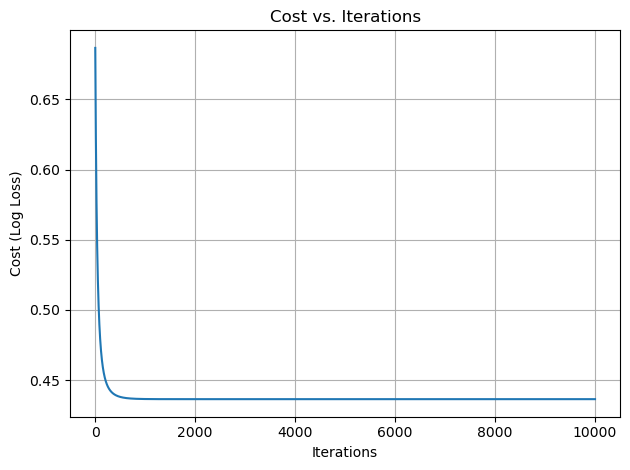

In [ ]:
# cost vs iterations plot

plt.plot(iteration_points, cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost (Log Loss)")
plt.title("Cost vs. Iterations")
plt.grid(True)
plt.tight_layout()